![ATARRI logos](img/logos.png)

# 4.4 Evaluation of coarse dust optical depth at 500nm with Library mode

#### Objective

The objective of this notebook is to introduce Providentia's Library mode, and apply its backend functionalities for dust evaluations.

##  Introduction to Library Mode

Library Mode allows users to exploit Providentia's backend functionalities and apply them directly inside scripts. Through the library, we will evaluate MONARCH forecasts against coarse dust optical depth at 500nm.

To access the library, we must import Providentia from the directory where it is stored. This only applies if we need to run our script outside the Providentia directory.

In [1]:
import sys
sys.path.append('/home/jupyter-tvintimi/atarri/tools/providentia')

After this, we are free to load Providentia as a module:

In [2]:
import providentia as prv

In [3]:
%matplotlib inline

Note that, if you would like to run your own Jupyter notebooks inside the Providentia directory, you can use Notebook mode via the terminal with the following command:

~~~
./bin/providentia --notebook
~~~

With this method, you avoid having to import the Providentia directory path and load the modules (as Notebook mode will do this for you), and you can directly skip to loading Providentia as a module.

## Accessing the other Providentia modes

First, we will create the Providentia object. Just as we did for our optical depth at 500nm, we have a .config file for coarse AOD at 500nm, `atarri_od500aerocoarse.conf`, which we will load as follows:

In [4]:
provi = prv.Providentia('atarri_od500aerocoarse.conf', section='All·Selected_BDRC_2021')

Through Library mode, we can access the other Providentia modes that we have looked at so far with the following lines:

<table>
    <tr>
        <th>Mode</th>
        <th>Call</th>
    </tr>
    <tr>
        <td>Download</td>
        <td><code>provi.download()<code></td>
    </tr>
    <tr>
        <td>Interpolation</td>
        <td><code>provi.interpolation()<code></td>
    </tr>
    <tr>
        <td>Dashboard</td>
        <td><code>provi.dashboard()<code></td>
    </tr>
    <tr>
        <td>Report</td>
        <td><code>provi.report()<code></td>
    </tr>
    <tr>
        <td>Library</td>
        <td><code>provi.load()<code></td>
    </tr>
</table>

## Reading and filtering data from a .conf file

Just as we did for our optical depth at 500nm, we have a .config file for coarse AOD at 500nm, `atarri_od500aerocoarse.conf`.

![O'Neill configuration](img/29_oneill-conf.png)

We will read this .conf as follows:

In [5]:
provi.load()

Updating file tree /home/jupyter-tvintimi/atarri/tools/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/jupyter-tvintimi/atarri/tools/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - nasa-aeronet/oneill_v3-lev15|od500aerocoarse
MODELS
 - monarch-regional-000

Resetting data filters to when class was initialised, loading All·Selected_BDRC_2021 subsection filters.
Filtering data


This creates a class instance that reads our data and applies filters according to the input .conf file.

Only one section-subsection pair from the .conf file may be read and filtered by the library at a single time, except in the creation of plots with the `multispecies` option. When we have more than one pair defined in the file, we can set our desired pair by passing the section and/or subsection arguments as shown in the following example:

~~~
provi = prv.load('interactive_template.conf', section='OTHERSECTION', subsection='OTHERSUBSECTION')
~~~

In our case, since we did not specify a subsection, Providentia automatically takes our `All` section together with the first subsection `Selected_BDRC_2021`.

In case we wanted to review what our current configurations are, we have the option to print them with the following line:

In [6]:
# print .conf
provi.print_config()

[All]
network = nasa-aeronet/oneill_v3-lev15 
species = od500aerocoarse
resolution = 3hourly
start_date = 20250301
end_date = 20250401
experiments = monarch-regional-000
temporal_colocation = True
spatial_colocation = True
report_summary = True
report_stations = False
statistic_mode = Flattened
timeseries_statistic_aggregation=Mean
harmonise_summary = False

    [[Selected_BDRC_2021]]
     station_name = keep: La_Crau, Capo_Verde, Barcelona, SEDE_BOKER, Banizoumbou, CRETE, Izana, Teide, Ilorin, IMAA_Potenza, IMS-METU-ERDEMLI, El_Arenosillo, Modena, Lampedusa, Rome_Tor_Vergata, Lecce_University, Kuwait_University, ATHENS-NOA, Palencia, Toulon, Evora, Cabo_da_Roca, Messina, Thessaloniki, IER_Cinzana, Granada, Mezaira, Saada, Santa_Cruz_Tenerife, OHP_OBSERVATOIRE, Tamanrasset_INM, Eilat, Burjassot, La_Laguna, Ersa, Arcachon, Zinder_Airport, Eforie, IASBS, CUT-TEPAK, Tabernas_PSA-DLR, Montsec, Palma_de_Mallorca, Masdar_Institute, Magurele_Inoe, Coruna, Cairo_EMA_2, KAUST_Campus, Madrid, Ti

After we have read and filtered our data, it will remain filtered until we reset the filter in the following way:

In [7]:
provi.reset()

Resetting all data filters.
Filtering data


IMPORTANT: We can overwrite arguments in the .conf file directly in the script. We can pass each argument when initiating the class instance, such as:

In [8]:
provi = prv.Providentia('atarri_od500aerocoarse.conf', start_date='202503', end_date='202504')
provi.load()

Updating file tree /home/jupyter-tvintimi/atarri/tools/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/jupyter-tvintimi/atarri/tools/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - nasa-aeronet/oneill_v3-lev15|od500aerocoarse
MODELS
 - monarch-regional-000

Resetting data filters to when class was initialised, loading All·Selected_BDRC_2021 subsection filters.
Filtering data


Tip: If you need to turn off temporal colocation for your plots, you can add `temporal_colocation=False` as an argument and reload the configuration file.

The data we have read and filtered can be saved to a file wih `provi.save`. We will save this as a netCDF file as follows:

In [9]:
# save data to netCDF
provi.save(format='nc')

Data saved to /home/jupyter-tvintimi/atarri/tools/providentia/saved_data/PRV_20260311_1049.nc


Data can also be returned directly in memory with specific formats.

In [10]:
# return data in memory (in Xarray format)
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 110kB
Dimensions:                                                         (
                                                                     data_label: 2,
                                                                     station_nasa-aeronet_oneill_v3-lev15|od500aerocoarse: 50,
                                                                     time: 248,
                                                                     month: 1)
Coordinates:
  * time                                                            (time) datetime64[ns] 2kB ...
Dimensions without coordinates: data_label,
                                station_nasa-aeronet_oneill_v3-lev15|od500aerocoarse,
                                month
Data variables:
    data_labels                                                     (data_label) <U20 160B ...
    nasa-aeronet_oneill_v3-lev15|od500aerocoarse_data               (data_label, station_nasa-aeronet_oneill_v3-lev15|od500aerocoarse, time) float32 99kB ...
    nasa-aeronet_oneill_v3-lev15|od500aerocoarse_station_reference  (station_nasa-aeronet_oneill_v3-lev15|od500aerocoarse, month) <U19 4kB ...
    nasa-aeronet_oneill_v3-lev15|od500aerocoarse_longitude          (station_nasa-aeronet_oneill_v3-lev15|od500aerocoarse, month) float64 400B ...
    nasa-aeronet_oneill_v3-lev15|od500aerocoarse_latitude           (station_nasa-aeronet_oneill_v3-lev15|od500aerocoarse, month) float64 400B ...
    nasa-aeronet_oneill_v3-lev15|od500aerocoarse_station_name       (station_nasa-aeronet_oneill_v3-lev15|od500aerocoarse, month) <U19 4kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

If we wanted to avoid extracting the entire read dataset, we can instead extract a specific variable in memory. Let's try this out with the `station_name`:

In [11]:
station_name_var = provi.variable('nasa-aeronet_oneill_v3-lev15|od500aerocoarse_station_name')
station_name_var

array([['ATHENS_NTUA'],
       ['AgiaMarina_Xyliatou'],
       ['Badajoz'],
       ['Barcelona'],
       ['Burjassot'],
       ['CUT-TEPAK'],
       ['Cabo_da_Roca'],
       ['Cairo_EMA_2'],
       ['Capo_Verde'],
       ['Casablanca_Platform'],
       ['Coruna'],
       ['Dakar_Belair'],
       ['El_Arenosillo'],
       ['Ersa'],
       ['Evora'],
       ['FORTH_RSLab'],
       ['Granada'],
       ['IASBS'],
       ['IER_Cinzana'],
       ['IMS-METU-ERDEMLI'],
       ['Ilorin'],
       ['Izana'],
       ['KAUST_Campus'],
       ['Koforidua_ANUC'],
       ['LAMTO-STATION'],
       ['LAQUILA_Coppito'],
       ['Lampedusa'],
       ['Magurele_Inoe'],
       ['Medenine-IRA'],
       ['Mezaira'],
       ['Migal'],
       ['Modena'],
       ['Momuy_MF'],
       ['Murcia'],
       ['Napoli_CeSMA'],
       ['OHP_OBSERVATOIRE'],
       ['Palencia'],
       ['Rome_La_Sapienza'],
       ['Rome_Tor_Vergata'],
       ['SEDE_BOKER'],
       ['Santa_Cruz_Tenerife'],
       ['Section-7_Platform'],
  

## Using the library for dust model evaluation

One of the most important features of Library mode is the fact that we can reproduce the plots we can create in Dashboard mode. We will use these functions to report showcase different statistics from our study area, simulating the reports produced for the Barcelona Dust Regional Center.

We will first visualise our observations Mean across all stations. We will make use of the `plot` function, and define the maximum `map extent`. We will also set `plot_options = ['domain']` to add the model grid on top of the map.

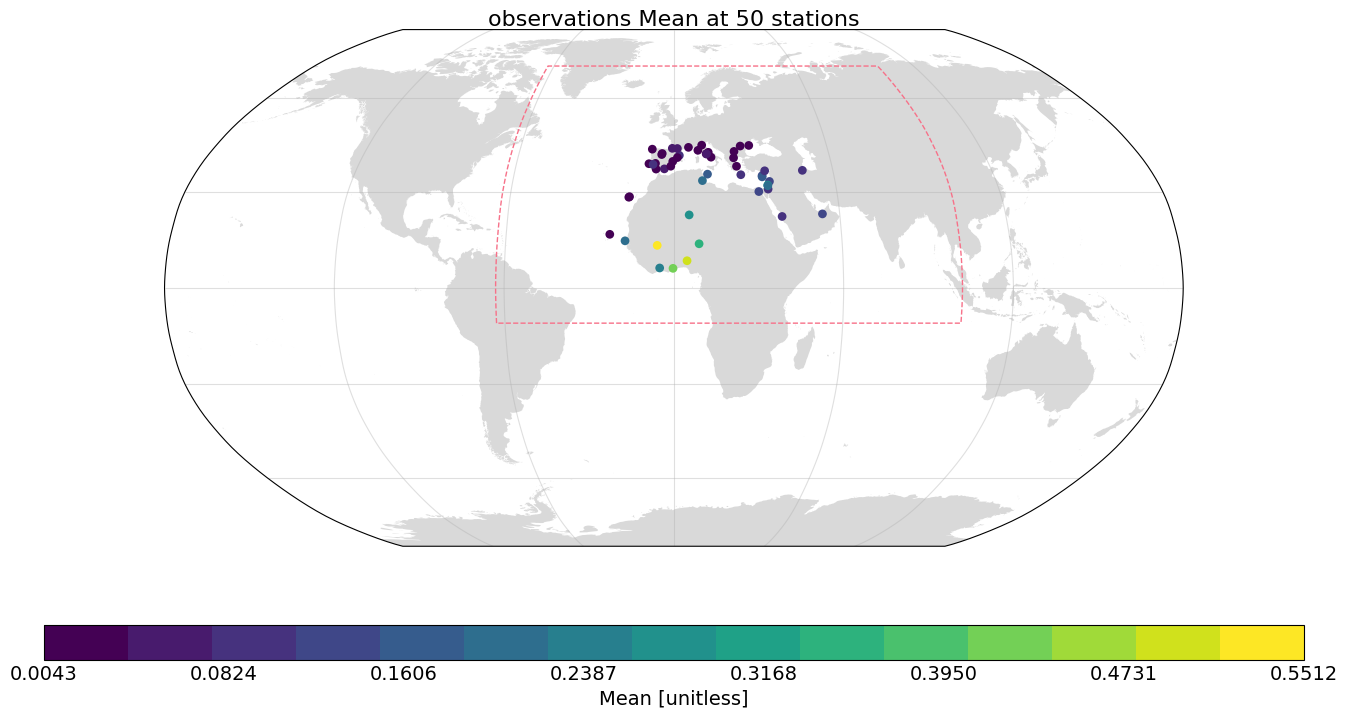

In [12]:
# make a map plot (Mean statistic)
provi.plot('map-Mean', labela='observations', map_extent=[-180, 180, -90, 90], plot_options=['domain'], legend=False)

We can also make a `statsummary` for a quick statistical look at our model. We can look at basic and bias statistics, as well as toggle the multispecies option.

Resetting data filters to when class was initialised, loading All·Selected_BDRC_2021 subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading All·Mediterranean subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading All·NorthAfrica subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading All·Sub-Sahara subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading All·MiddleEast subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading All·SouthernEurope subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading All·Selected_BDRC_2021 subsection filters.
Filtering data


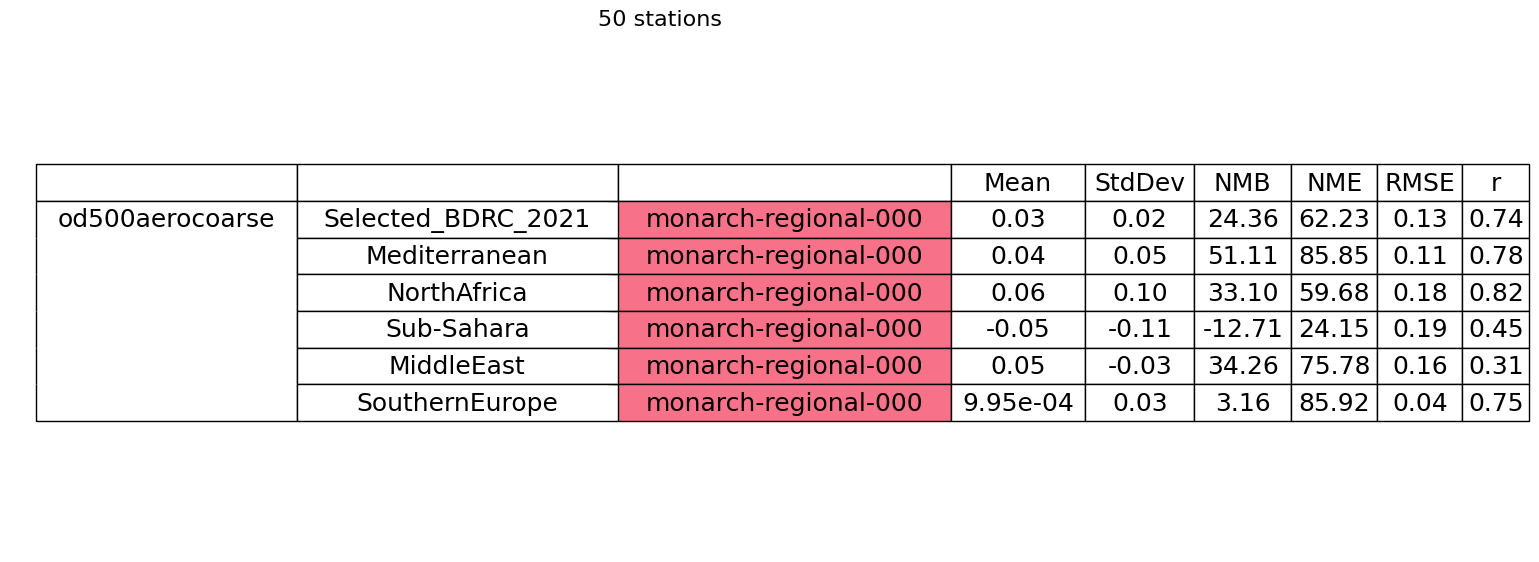

In [13]:
#provi.reset()
provi.plot('statsummary', multispecies=True, bias=True)

Now that we have an initial view, we will move to make a local map with bias statistics, as this will help us to quantify the model's performance. We will plot the `r`, `MFE` and `MFB` map statistic, but we will change our extent and title to reflect the Eastern Mediterranean. This will tell us:

- The linear relationship between observations and model predictions, and the proportion of variance explained (r).
- The mean absolute fractional difference between a model and observations, in percentage (MFE).
- The average fractional difference between a model and observations, as percentage (MFB).

For more detailed information on statistics available through Providentia, please see the [Statistics](https://providentia.readthedocs.io/en/latest/Statistics.html#basic-statistics) page.

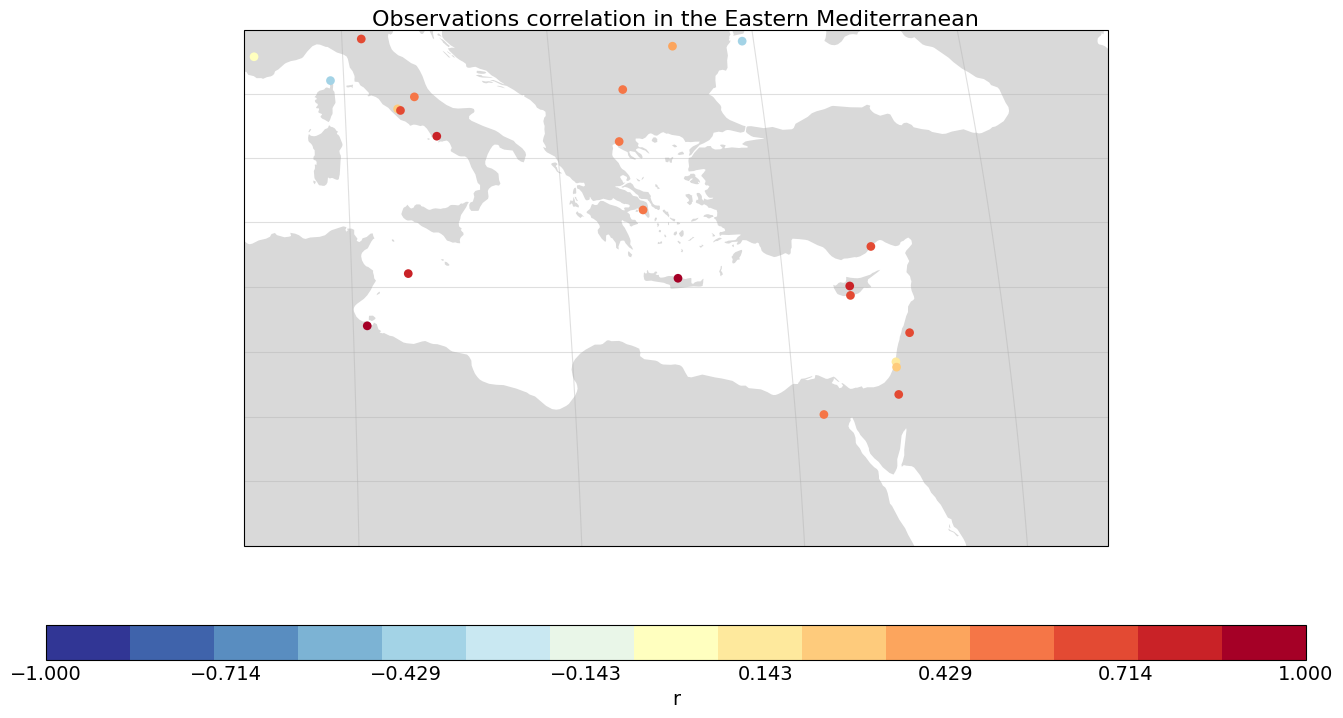

In [14]:
provi.plot('map-r',
           map_extent=[5, 45, 25, 45],
           labela = 'observations',
           labelb = 'monarch-regional-000',
           title='Observations correlation in the Eastern Mediterranean',
           legend = False
          )

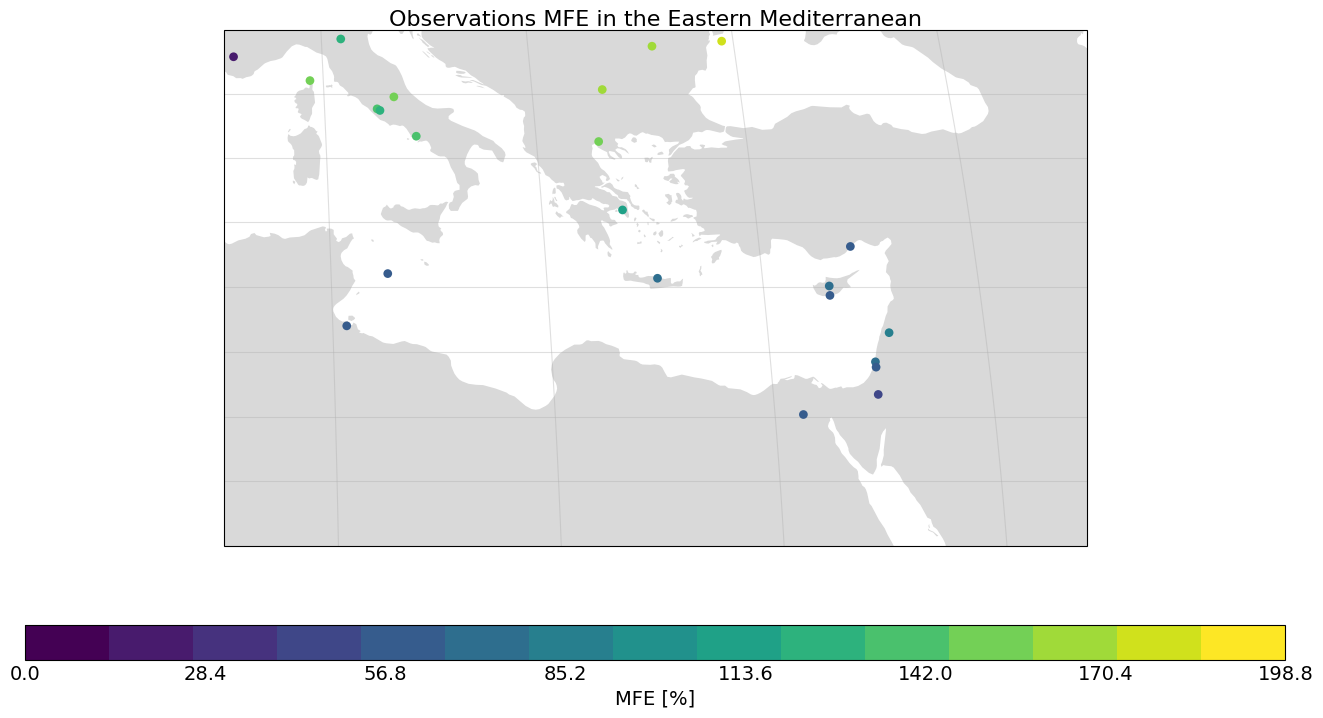

In [15]:
provi.plot('map-MFE',
           map_extent=[5, 45, 25, 45],
           labela = 'observations',
           labelb = 'monarch-regional-000',
           title='Observations MFE in the Eastern Mediterranean',
           legend = False
          )

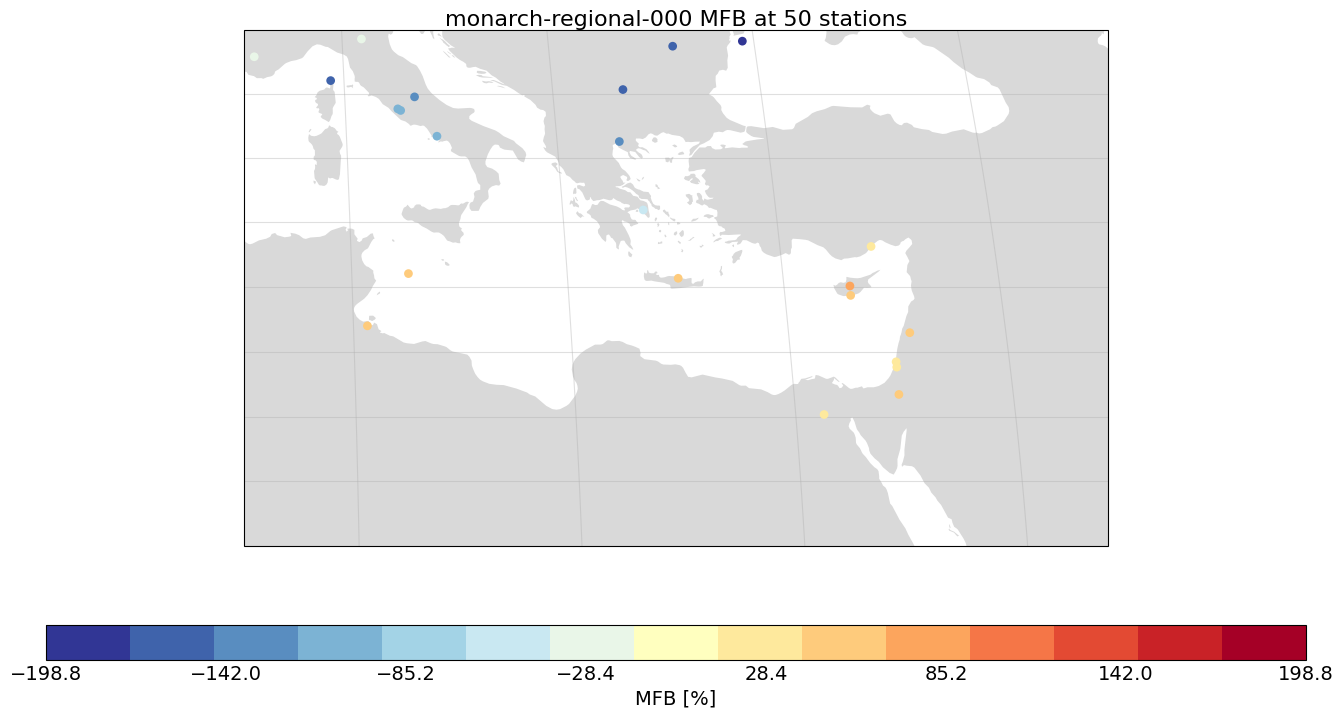

In [16]:
provi.plot('map-MFB',
           labela='observations',
           labelb='monarch-regional-000',
           map_extent=[5, 45, 25, 45]
          )

We have gained a brief picture from the Eastern Mediterranean, but what about specific Mediterranean stations?

We will repeat our analysis in selected stations affected by our dust event in March 2025. We will evaluate coarse AOD starting from those nearest to the source, so we will select the following stations in order:

- Migal, Lebanon
- IMS-METU-ERDEMLI, Turkey
- CUT-TEPAK, Cyprus
- FORTH_RSLab, Greece

First we will look at these stations together, then we will look at them individually. We will take a look at the progression of the dust plume over these stations, and focus on arrival times, magnitude differences, duration of observed vs modelled event, etc.

In [17]:
provi.reset()
provi.filter_station(['Migal', 'IMS-METU-ERDEMLI', 'CUT-TEPAK', 'FORTH_RSLab'])

Resetting all data filters.
Filtering data
Filtering data


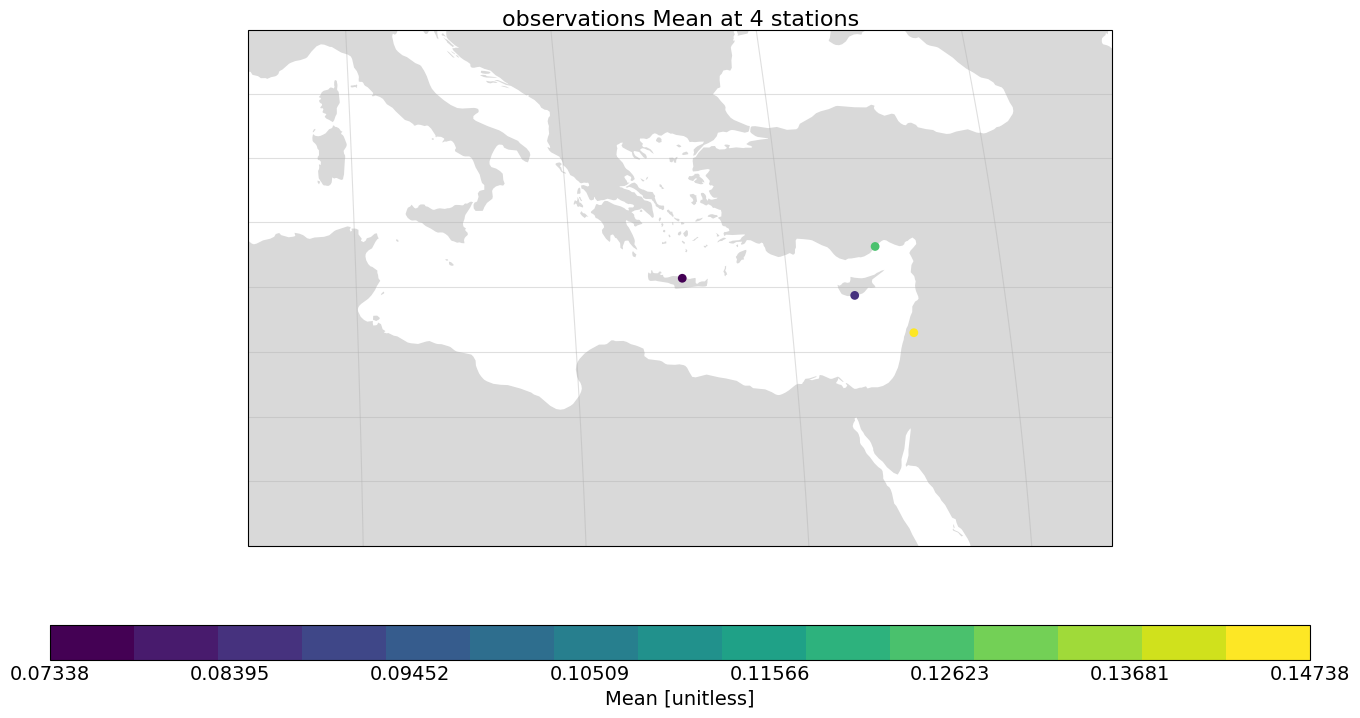

In [18]:
provi.plot('map-Mean',
            labela='observations',
            labelb='monarch-regional-000',
            map_extent=[5, 45, 25, 45]
            )

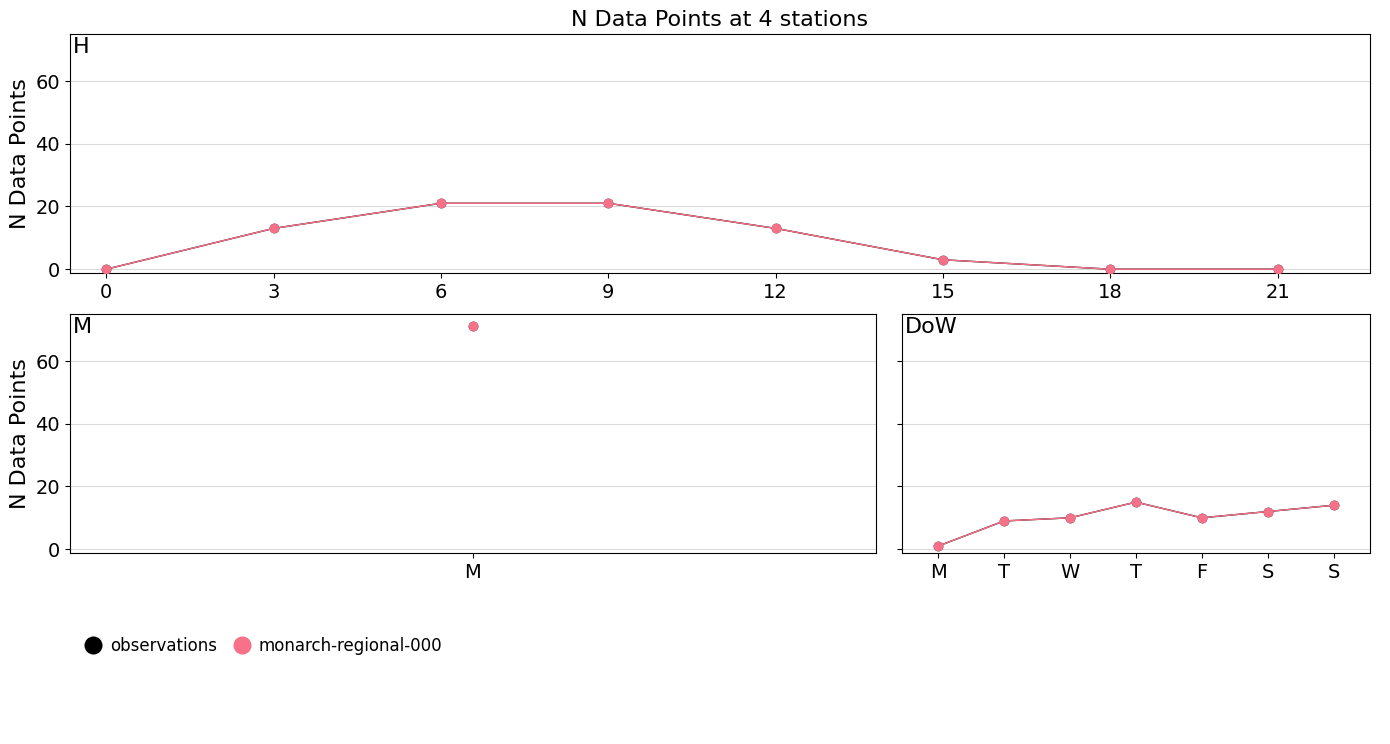

In [19]:
provi.plot('periodic-NData')

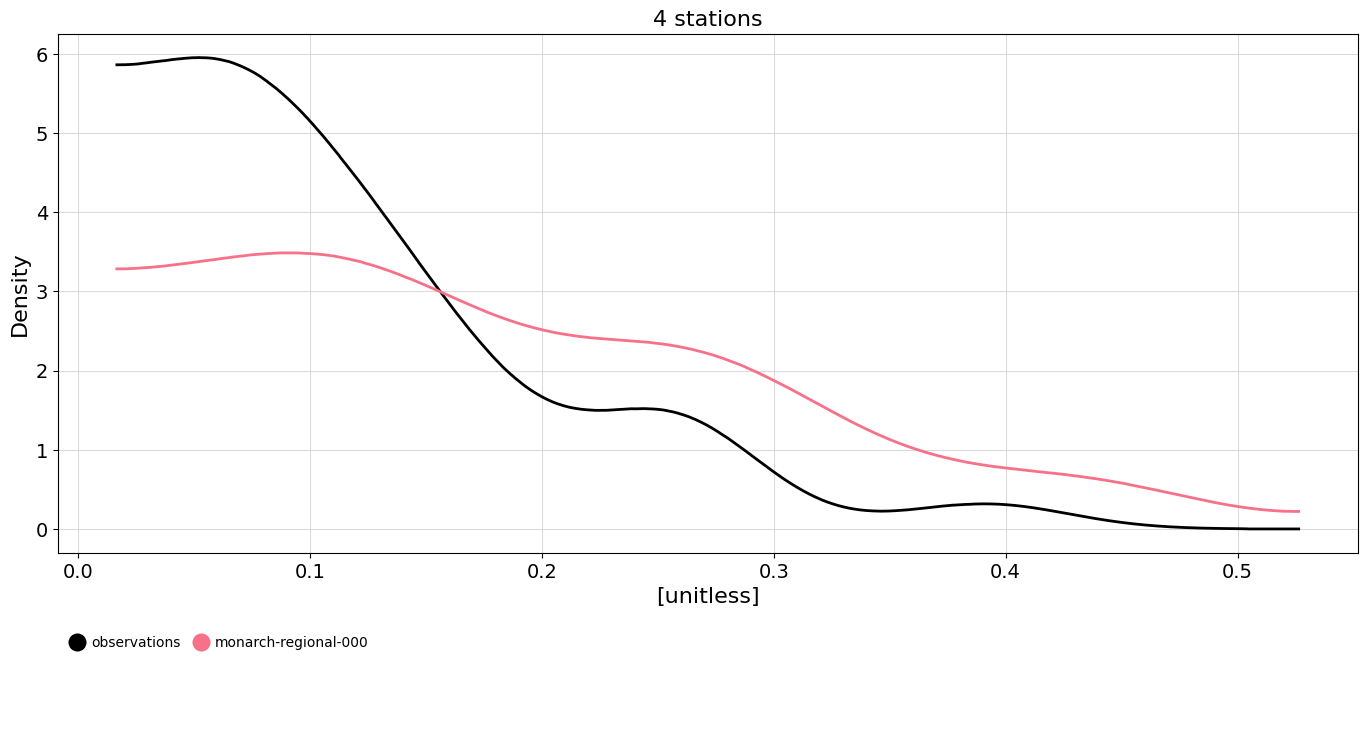

In [20]:
provi.plot('distribution')

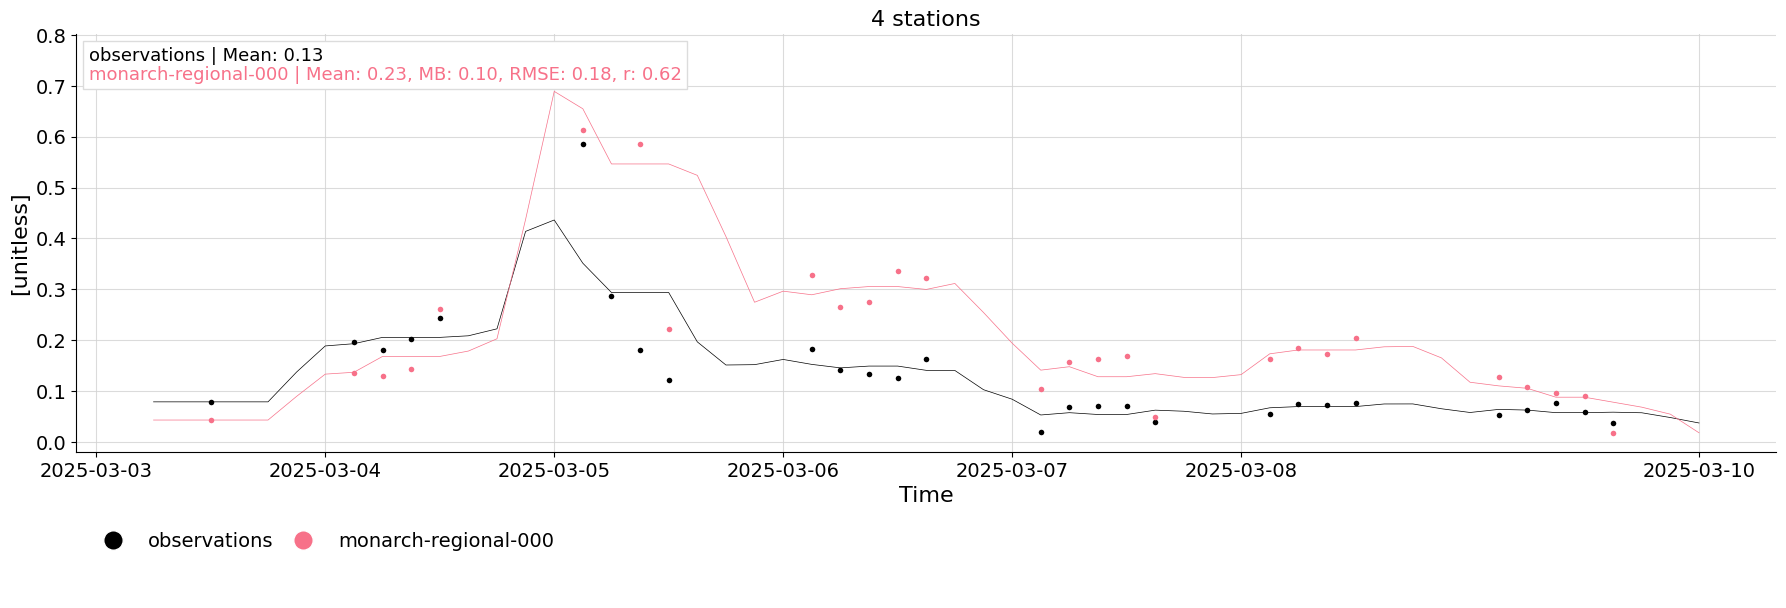

In [21]:
provi.plot('timeseries', annotate=True, smooth=5)

Resetting all data filters.
Filtering data
Filtering data


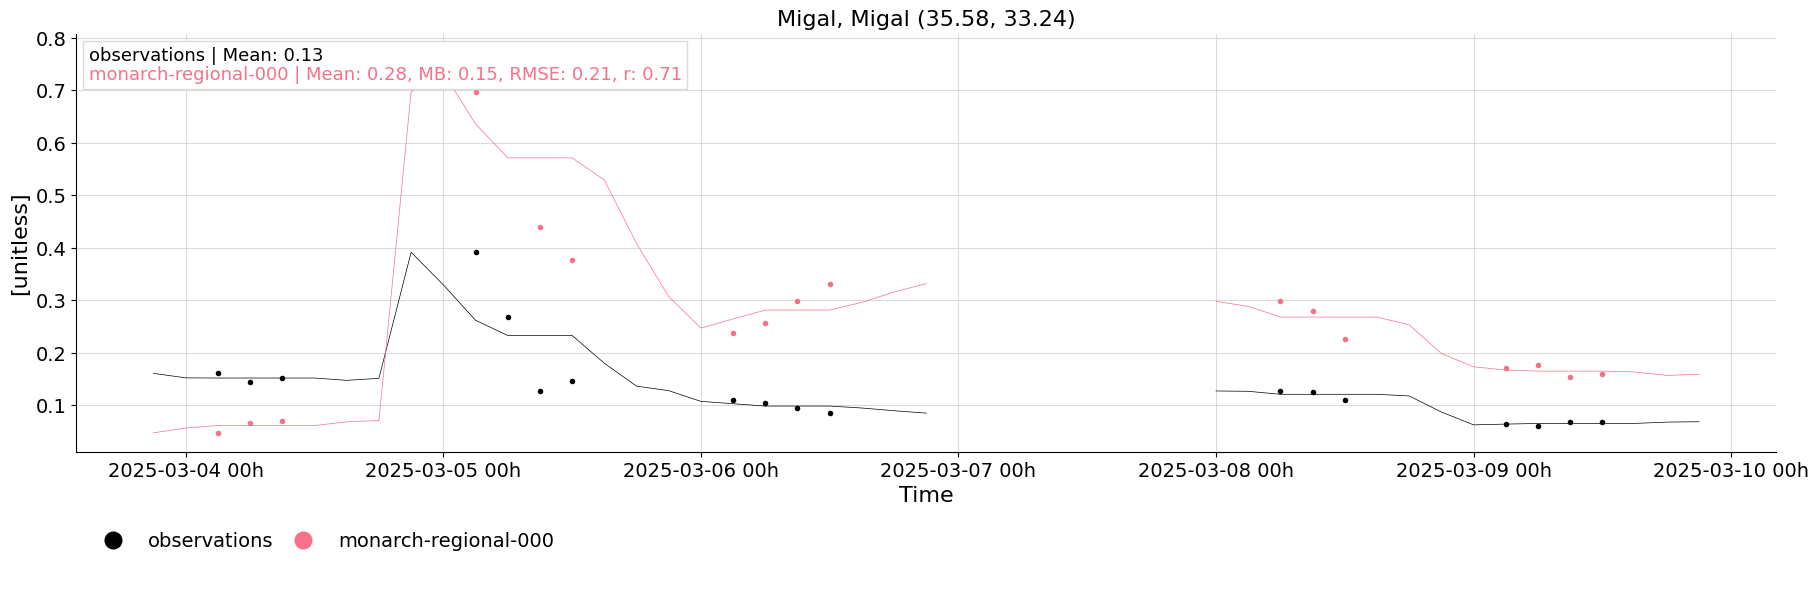

In [23]:
provi.reset()
provi.filter_station('Migal')
provi.plot('timeseries', annotate=True, smooth=5)

Resetting all data filters.
Filtering data
Filtering data


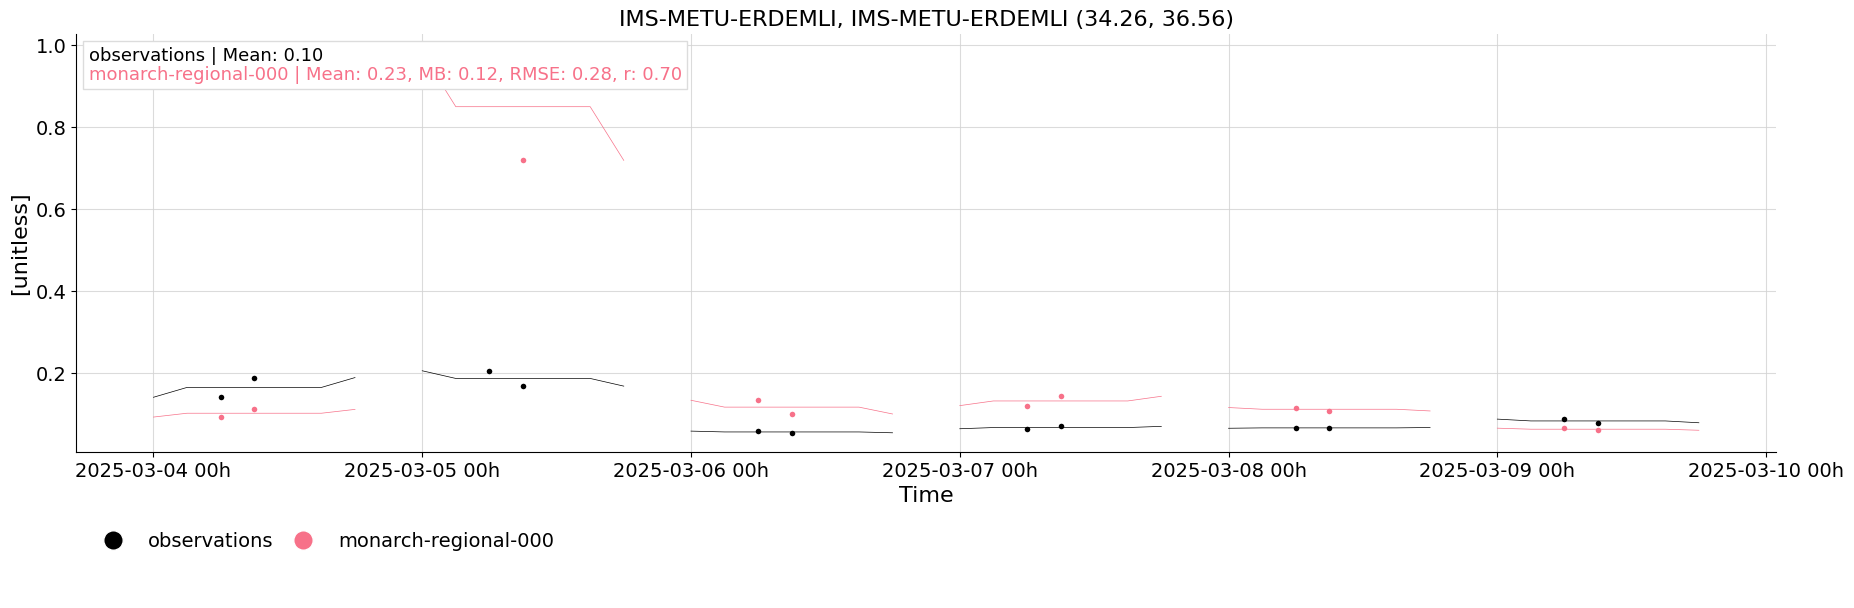

In [24]:
provi.reset()
provi.filter_station('IMS-METU-ERDEMLI')
provi.plot('timeseries', annotate=True, smooth=5)

Resetting all data filters.
Filtering data
Filtering data


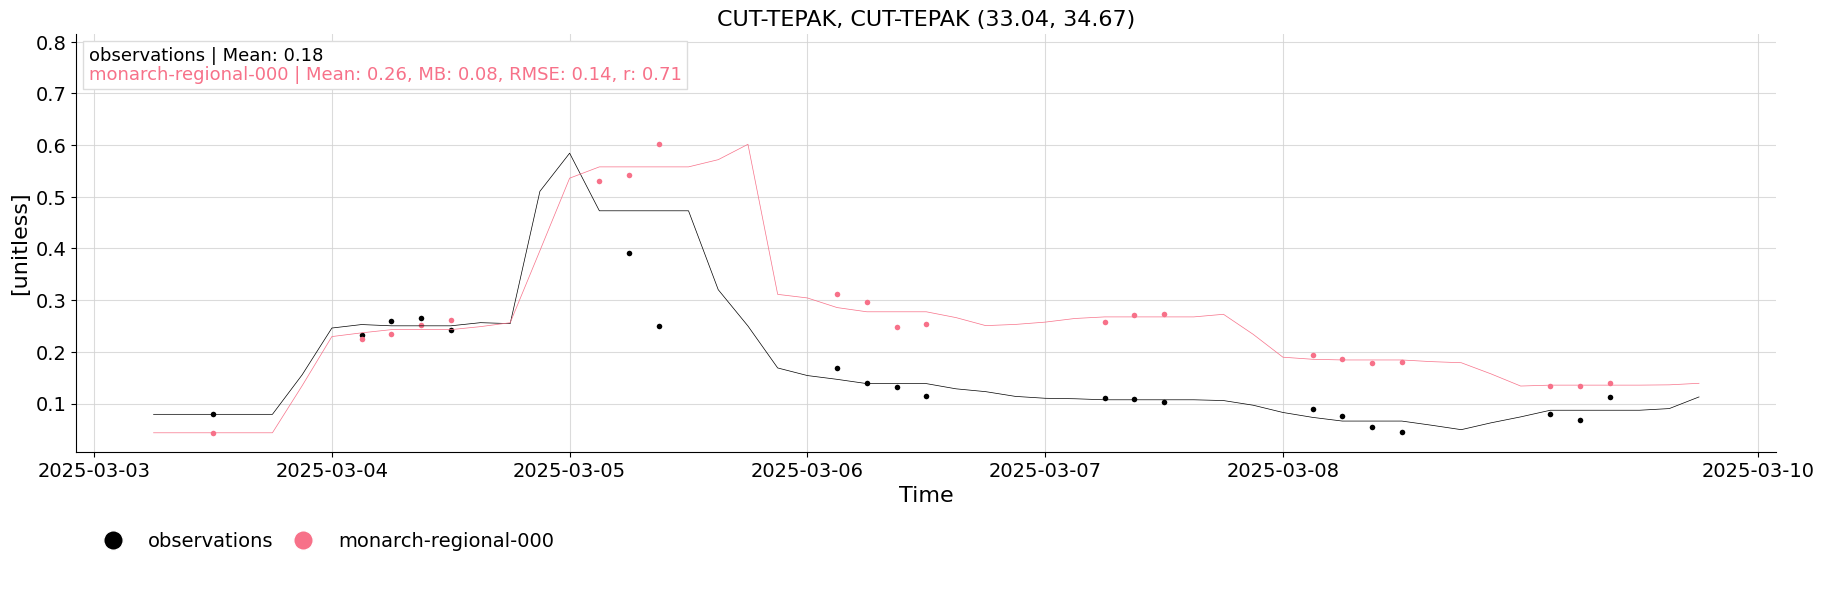

In [25]:
provi.reset()
provi.filter_station('CUT-TEPAK')
provi.plot('timeseries', annotate=True, smooth=5)

Resetting all data filters.
Filtering data
Filtering data


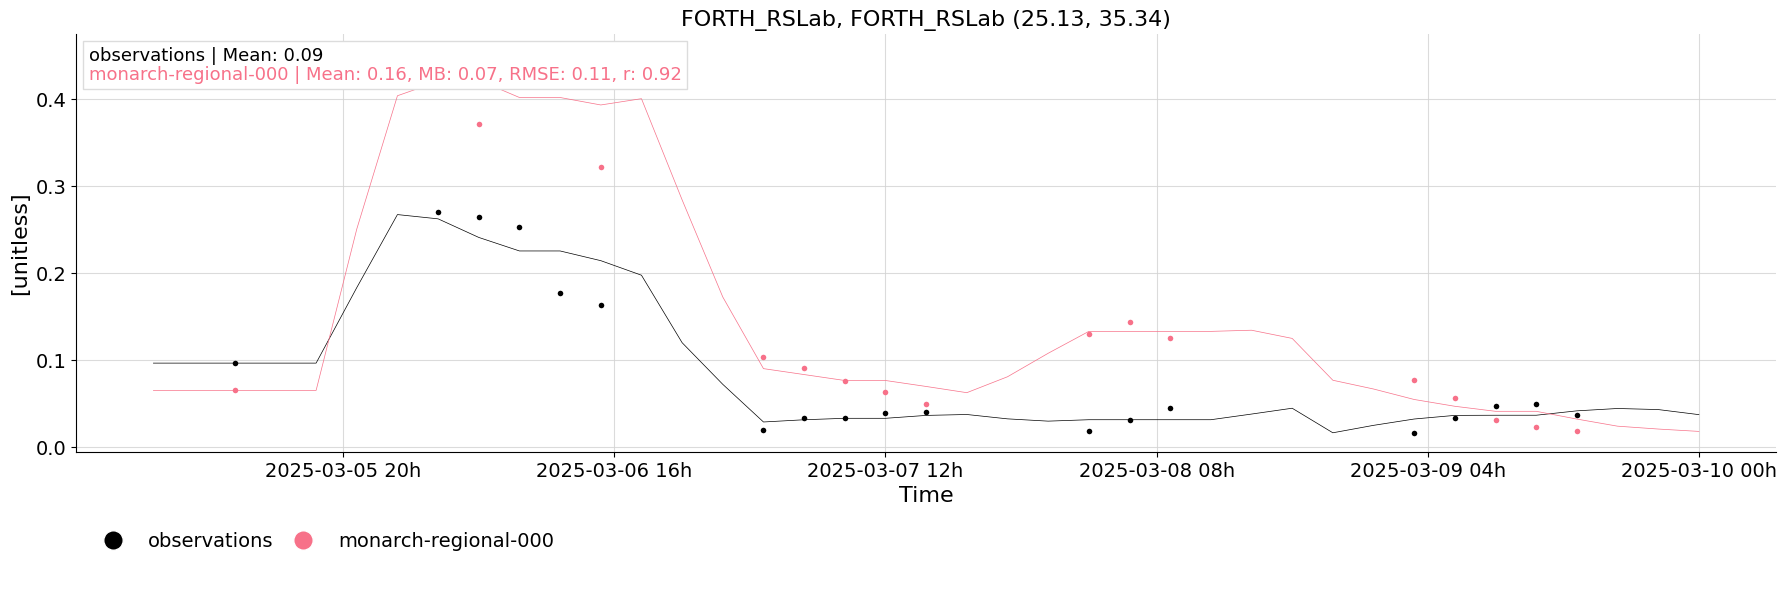

In [26]:
provi.reset()
provi.filter_station('FORTH_RSLab')
provi.plot('timeseries', annotate=True, smooth=5)

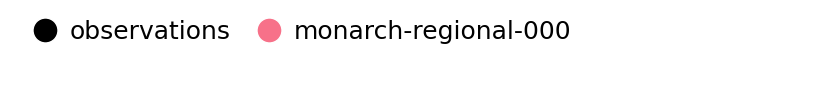

In [27]:
# make a legend plot
provi.plot('legend')

You can use these results to compare the evaluation of Direct Sun AOD to get a fuller picture of your model's performance.

## References and further reading

For more information on the Library, please check out the [Library page](https://providentia.readthedocs.io/en/latest/Library.html) of the Providentia docs.

Providentia is an internal tool developed at BSC-CNS. For any issues, please contact the active developers: [Dene Bowdalo](mailto:dene.bowdalo@bsc.es), [Alba Vilanova](mailto:alba.vilanova@bsc.es) and [Paula Serrano](mailto:paula.serrano@bsc.es).

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT4-3-dashboard_mode-od550du.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT4-5-Workshop.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr>
</table>